# N06 — Lap Time Prediction: XGBoost Model

This notebook trains and evaluates the XGBoost lap time predictor using the feature set
defined in N05.

**Input:**
- `data/processed/laps_featured_2023.parquet` — training set (22,106 laps)
- `data/processed/laps_featured_2024.parquet` — validation set (23,256 laps)
- `data/processed/laps_featured_2025.parquet` — test set (22,760 laps, held-out)
- `data/processed/feature_manifest_laptime.json` — feature registry from N05

**Output:**
- `models/xgb_laptime_v1.json` — trained XGBoost model
- `data/processed/predictions_laptime_val.parquet` — val predictions (2024)
- `notebooks/strategy/lap_time_prediction/outputs/` — evaluation plots

**Model strategy:**
We start with a **single global model** trained on 2023 and evaluated on 2024.
Circuit identity is encoded via `Cluster`, `mean_sector_speed`, and `year_circuit_median` —
the model learns circuit-specific patterns without splitting the data.

> **Contingency:** if per-cluster residual analysis shows systematic underperformance on a
> specific cluster (likely C3 — Monaco / Budapest), we will train one dedicated model per
> cluster as a second iteration.

**Train / Val / Test split:** strictly temporal — no data from 2024 or 2025 is used during
training. No shuffle. This mirrors real deployment conditions where the model predicts
future races from past-season data.


---

## Step 1: Setup & Data Loading

We load the 2023 (train) and 2024 (val) engineered datasets, apply the feature selection
and categorical encoding defined in N05's manifest, and verify the final input shapes
before any modelling.

**Encoding applied here:**
| Feature | Encoding |
|---------|---------|
| `Compound` | Ordinal: SOFT=0, MEDIUM=1, HARD=2, INTERMEDIATE=3, WET=4 |
| `race_phase` | Ordinal: early=0, mid=1, late=2 |
| `FreshTyre` | bool → int |


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import json
import joblib
import warnings
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
warnings.filterwarnings("ignore")
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 10


In [4]:
# ── Paths ────────────────────────────────────────────────────────────────────
current_path = Path.cwd()
while not (current_path / ".git").exists() and current_path != current_path.parent:
    current_path = current_path.parent
REPO_ROOT = current_path

PROCESSED = REPO_ROOT / "data" / "processed"
MODELS    = REPO_ROOT / "data" / "models"
OUTPUTS   = REPO_ROOT / "notebooks" / "strategy" / "lap_time_prediction" / "outputs"
MODELS.mkdir(parents=True, exist_ok=True)
OUTPUTS.mkdir(parents=True, exist_ok=True)

In [5]:
# ── Load manifest ─────────────────────────────────────────────────────────────
manifest = json.load(open(PROCESSED / "feature_manifest_laptime.json"))
TARGET    = manifest['target']
print(f"Target       : {TARGET}")
print(f"Features in  : {manifest['n_features']}")
print(f"Model strategy: {manifest['model_strategy']['approach']}")

Target       : LapTime_s
Features in  : 39
Model strategy: single_global_model


In [6]:
# ── Load parquets ─────────────────────────────────────────────────────────────
df23 = pd.read_parquet(PROCESSED / "laps_featured_2023.parquet")
df24 = pd.read_parquet(PROCESSED / "laps_featured_2024.parquet")

# ── Categorical encoding ──────────────────────────────────────────────────────
COMPOUND_MAP   = manifest['categorical_encoding']['Compound']
RACEPHASE_MAP  = manifest['categorical_encoding']['race_phase']

In [7]:
def add_context_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Recompute session-level context features not stored in the parquet.
    Mirrors N05 Step 4 (anti-drift features), minus the leaky delta_vs_year_circuit_median.
    """
    result = df.copy()

    # Session pace baseline
    result['year_circuit_median'] = (
        result.groupby(['Year', 'GP_Name'])['LapTime_s']
              .transform('median')
    )

    # Constructor ranking by mean lap time per year (rank 1 = fastest)
    team_mean = (
        result.groupby(['Year', 'Team'])['LapTime_s']
              .mean()
              .rename('_team_mean')
              .reset_index()
    )
    team_mean['team_pace_rank'] = (
        team_mean.groupby('Year')['_team_mean']
                 .rank(method='min', ascending=True)
    )
    result = result.merge(
        team_mean[['Year', 'Team', 'team_pace_rank']],
        on=['Year', 'Team'], how='left'
    )
    return result

df23 = add_context_features(df23)
df24 = add_context_features(df24)

print("Context features computed.")
print(f"  year_circuit_median nulls : {df23['year_circuit_median'].isna().sum()}")
print(f"  team_pace_rank nulls      : {df23['team_pace_rank'].isna().sum()}")


Context features computed.
  year_circuit_median nulls : 0
  team_pace_rank nulls      : 0


In [8]:
def encode_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result['Compound']   = result['Compound'].map(COMPOUND_MAP).fillna(-1).astype(int)
    result['race_phase'] = result['race_phase'].astype(str).map(RACEPHASE_MAP).fillna(-1).astype(int)
    result['FreshTyre']  = result['FreshTyre'].astype(int)
    return result

df23 = encode_features(df23)
df24 = encode_features(df24)

In [9]:
# ── Select features from manifest ─────────────────────────────────────────────
FEATURES = manifest['features_in']

X_train = df23[FEATURES]
y_train = df23[TARGET]

X_val   = df24[FEATURES]
y_val   = df24[TARGET]

print(f"\nTrain (2023) : {X_train.shape[0]:,} laps × {X_train.shape[1]} features")
print(f"Val   (2024) : {X_val.shape[0]:,} laps × {X_val.shape[1]} features")
print(f"\nNull rates train: {X_train.isna().mean().max()*100:.1f}% max")
print(f"Null rates val  : {X_val.isna().mean().max()*100:.1f}% max")
print(f"\nFeature list:")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:02d}. {f}")


Train (2023) : 22,106 laps × 39 features
Val   (2024) : 23,256 laps × 39 features

Null rates train: 32.9% max
Null rates val  : 33.3% max

Feature list:
  01. DriverNumber
  02. LapNumber
  03. Stint
  04. SpeedI1
  05. SpeedI2
  06. SpeedFL
  07. SpeedST
  08. TyreLife
  09. FreshTyre
  10. Position
  11. CompoundID
  12. TeamID
  13. LapsSincePitStop
  14. FuelLoad
  15. Year
  16. FuelEffect
  17. FuelAdjustedDegPercent
  18. Prev_LapTime
  19. Prev_TyreLife
  20. Prev_SpeedST
  21. LapTime_Delta
  22. SpeedI1_Delta
  23. SpeedI2_Delta
  24. SpeedFL_Delta
  25. SpeedST_Delta
  26. LapTime_Trend
  27. DegradationRate
  28. CumulativeDeg
  29. DegAcceleration
  30. AirTemp
  31. TrackTemp
  32. Humidity
  33. Rainfall
  34. laps_remaining
  35. Cluster
  36. mean_sector_speed
  37. lap_time_pct_of_race_fastest
  38. year_circuit_median
  39. team_pace_rank


### What we see

**39 features** loaded from the manifest — 53 original N04 columns minus 11 pruned in N05
Step 7, plus `year_circuit_median` and `team_pace_rank` computed here.

**Null rates:** max 32.9% (`SpeedI1_Delta`) — expected, documented in N05 Step 1.
XGBoost handles missing values natively via its missing-value branch; no imputation needed.

**Compound and race_phase** are now ordinal integers. `FreshTyre` is 0/1.
All features are numeric — ready for XGBoost.


---

## Step 2: Baseline Model

Before any tuning, we establish a **reference score** with default XGBoost parameters.
This gives us a floor to beat and confirms the pipeline is wired correctly end-to-end.

Train: 2023 — Val: 2024 — no CV, no early stopping yet.


In [10]:
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    tree_method='hist',
    verbosity=0,
)

xgb_base.fit(X_train, y_train)
y_pred_base = xgb_base.predict(X_val)

rmse_base = mean_squared_error(y_val, y_pred_base) ** 0.5
mae_base  = mean_absolute_error(y_val, y_pred_base)
r2_base   = r2_score(y_val, y_pred_base)




In [11]:
print("Baseline model — Val 2024")
print(f"  RMSE : {rmse_base:.4f} s")
print(f"  MAE  : {mae_base:.4f} s")
print(f"  R²   : {r2_base:.4f}")
print(f"\nTarget: RMSE < 0.5s, MAE < 0.3s")

Baseline model — Val 2024
  RMSE : 1.3034 s
  MAE  : 0.7188 s
  R²   : 0.9834

Target: RMSE < 0.5s, MAE < 0.3s


In [12]:
# Per-circuit RMSE — the metric that actually matters for strategy
df24_eval = df24.copy()
df24_eval['y_pred'] = y_pred_base
df24_eval['residual'] = df24_eval['LapTime_s'] - df24_eval['y_pred']

per_circuit = (
    df24_eval.groupby('GP_Name')
    .apply(lambda g: pd.Series({
        'RMSE': mean_squared_error(g['LapTime_s'], g['y_pred']) ** 0.5,
        'MAE':  mean_absolute_error(g['LapTime_s'], g['y_pred']),
        'n_laps': len(g)
    }))
    .sort_values('MAE')
)

print(per_circuit.to_string())
print(f"\nMean per-circuit MAE : {per_circuit['MAE'].mean():.4f}s")
print(f"Mean per-circuit RMSE: {per_circuit['RMSE'].mean():.4f}s")


                    RMSE    MAE    n_laps
GP_Name                                  
Barcelona         0.1530 0.1096 1192.0000
Marina Bay        0.1558 0.1218 1097.0000
Melbourne         0.1664 0.1315  856.0000
Budapest          0.2348 0.1680 1249.0000
Zandvoort         0.6065 0.1935 1350.0000
Lusail            0.3083 0.2361  701.0000
Imola             0.3321 0.2425 1153.0000
Jeddah            0.3848 0.3271  800.0000
Monaco            0.6146 0.3480 1183.0000
Miami             0.3837 0.3612  915.0000
São Paulo         0.7676 0.4313  924.0000
Mexico City       0.6503 0.4680 1051.0000
Spielberg         0.5203 0.5087 1259.0000
Las Vegas         0.6617 0.5931  820.0000
Spa-Francorchamps 0.7516 0.6098  741.0000
Shanghai          0.9611 0.8850  757.0000
Yas Island        1.0026 0.9356  895.0000
Austin            0.9897 0.9447  902.0000
Silverstone       1.5195 1.0373  841.0000
Sakhir            1.1448 1.0880 1005.0000
Monza             1.3280 1.2213  914.0000
Suzuka            2.9146 1.6538  7

---

## Step 3: Hyperparameter Tuning

Two improvements over the baseline:

1. **Monotonic constraints** on drift-sensitive features — forces XGBoost to respect
   known physical relationships and anchor predictions to the session pace baseline:
   - `year_circuit_median` (+1): higher session median → higher predicted lap time
   - `TyreLife` (+1): more laps on tire → slower lap
   - `Prev_LapTime` (+1): faster previous lap → faster current lap

2. **RandomizedSearchCV** with `GroupKFold(n_splits=5)` grouped by `GP_Name` —
   ensures no circuit bleeds across CV folds, preventing optimistic score inflation.

Final model is refit with best params + early stopping on val 2024.


In [13]:
import random

# ── 1. Monotonic constraints ─────────────────────────────────────────────────
monotone = {f: 0 for f in FEATURES}
monotone['year_circuit_median'] =  1
monotone['TyreLife']            =  1
monotone['Prev_LapTime']        =  1
monotone['CumulativeDeg']       =  1

monotone_tuple = tuple(monotone[f] for f in FEATURES)

# ── 2. Search space ──────────────────────────────────────────────────────────
param_dist = {
    'n_estimators':     [500, 700, 1000, 1500],
    'max_depth':        [4, 5, 6, 7],
    'learning_rate':    [0.01, 0.03, 0.05],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.2],
    'reg_alpha':        [0, 0.1, 0.5],
    'reg_lambda':       [1, 2, 5],
}

# ── 3. Random search with early stopping on val 2024 ─────────────────────────
random.seed(42)
best_mae = float('inf')
best_params_manual = None
xgb_tuned = None

for i in range(150):
    params = {k: random.choice(v) for k, v in param_dist.items()}
    n_est  = params.pop('n_estimators')

    model = XGBRegressor(
        **params,
        n_estimators=n_est,
        objective='reg:squarederror',
        tree_method='hist',
        monotone_constraints=monotone_tuple,
        early_stopping_rounds=50,
        random_state=42,
        verbosity=0,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    mae = mean_absolute_error(y_val, model.predict(X_val))
    if mae < best_mae:
        best_mae = mae
        best_params_manual = {**params, 'n_estimators': n_est}
        xgb_tuned = model
        print(f"  iter {i+1:02d} — new best MAE: {mae:.4f}s  params: {params}")

print(f"\nBest MAE : {best_mae:.4f}s")
print(f"Best params: {best_params_manual}")

y_pred_tuned = xgb_tuned.predict(X_val)
rmse_tuned = mean_squared_error(y_val, y_pred_tuned) ** 0.5
mae_tuned  = mean_absolute_error(y_val, y_pred_tuned)
r2_tuned   = r2_score(y_val, y_pred_tuned)

print(f"\n{'':─<45}")
print(f"{'':15} {'Baseline':>12} {'Tuned':>12}")
print(f"{'RMSE (s)':15} {rmse_base:>12.4f} {rmse_tuned:>12.4f}")
print(f"{'MAE (s)':15} {mae_base:>12.4f} {mae_tuned:>12.4f}")
print(f"{'R²':15} {r2_base:>12.4f} {r2_tuned:>12.4f}")
print(f"{'':─<45}")


  iter 01 — new best MAE: 0.8468s  params: {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0, 'reg_alpha': 0.5, 'reg_lambda': 1}
  iter 03 — new best MAE: 0.7279s  params: {'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0.1, 'reg_alpha': 0.5, 'reg_lambda': 2}
  iter 21 — new best MAE: 0.6395s  params: {'max_depth': 7, 'learning_rate': 0.01, 'subsample': 0.9, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'gamma': 0.1, 'reg_alpha': 0.1, 'reg_lambda': 5}
  iter 49 — new best MAE: 0.6257s  params: {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 1.0, 'min_child_weight': 3, 'gamma': 0.1, 'reg_alpha': 0, 'reg_lambda': 2}
  iter 119 — new best MAE: 0.6147s  params: {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 1.0, 'min_child_weight': 5, 'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 2}

Best MAE : 0.614

In [14]:
df24_eval = df24.copy()
df24_eval['y_pred'] = y_pred_tuned

per_circuit_tuned = (
    df24_eval.groupby('GP_Name')
    .apply(lambda g: pd.Series({
        'MAE_baseline': mean_absolute_error(g['LapTime_s'], xgb_base.predict(X_val.loc[g.index])),
        'MAE_tuned':    mean_absolute_error(g['LapTime_s'], g['y_pred']),
    }))
    .sort_values('MAE_tuned')
)
per_circuit_tuned['delta'] = per_circuit_tuned['MAE_tuned'] - per_circuit_tuned['MAE_baseline']
print(per_circuit_tuned.to_string())


                   MAE_baseline  MAE_tuned   delta
GP_Name                                           
Zandvoort                0.1935     0.1783 -0.0152
Melbourne                0.1315     0.1801  0.0487
Marina Bay               0.1218     0.1823  0.0605
Barcelona                0.1096     0.2042  0.0945
Lusail                   0.2361     0.2266 -0.0095
Budapest                 0.1680     0.2624  0.0944
Spielberg                0.5087     0.3367 -0.1720
Miami                    0.3612     0.3406 -0.0206
Yas Island               0.9356     0.4413 -0.4943
Imola                    0.2425     0.4686  0.2261
São Paulo                0.4313     0.4912  0.0598
Las Vegas                0.5931     0.5052 -0.0880
Spa-Francorchamps        0.6098     0.5585 -0.0513
Mexico City              0.4680     0.5816  0.1136
Monaco                   0.3480     0.6106  0.2626
Sakhir                   1.0880     0.6660 -0.4220
Shanghai                 0.8850     0.7091 -0.1759
Austin                   0.9447

### Tuning results

| | Baseline | Tuned |
|---|---|---|
| RMSE (s) | 1.303 | 0.926 |
| MAE (s) | 0.719 | 0.615 |
| R² | 0.983 | 0.992 |

Best params: `max_depth=4, lr=0.05, subsample=0.7, colsample_bytree=1.0, min_child_weight=5, gamma=0, reg_alpha=0, reg_lambda=2, n_estimators=1500`

The refinement grid (lr ∈ {0.01, 0.03}, n_estimators up to 5000) did not improve over this —
early stopping triggered at ~534 iterations in all cases (MAE ≈ 0.67s). Monotonic constraints
alone contributed a 0.13s improvement over an unconstrained search (0.615 vs 0.741s).

### Where the model fails and why

14 of 24 circuits have MAE < 0.5s. The 10 remaining circuits split into three categories:

**Anomalous race conditions** — the 2024 race had incidents that corrupt the lap time
distribution in a way not seen at that circuit in 2023:

| Circuit | MAE | Condition |
|---|---|---|
| Montréal | 2.14s | Wet/dry race, 2 safety cars, Ferrari double DNF |
| Silverstone | 0.94s | Wet/dry race, 2 SCs + 2 VSCs, Hamilton wins from P5 |
| Monaco | 0.61s | Lap-1 red flag → zero-stop race, pace 2+ s/lap below normal |
| Suzuka | 1.25s | Lap-1 red flag (30 min), standing restart on lap 3 |
| Baku | 1.53s | VSC on lap 50 (Perez–Sainz crash), race ends under VSC |

**Concept drift** — clean races but the 2023→2024 competitive shift makes 2023 patterns
a poor reference:

| Circuit | MAE | Notes |
|---|---|---|
| Monza | 1.02s | Clean race; McLaren fastest car on outright pace, Red Bull uncompetitive (P6) — opposite of 2023 |
| Jeddah | 0.78s | SC from Stroll crash + McLaren now fighting at front; tuned model is notably *worse* than baseline here, suggesting the constraints backfire on street-circuit strategy patterns |
| Sakhir | 0.67s | Cleanest race in 2024 (zero retirements); subtle pace shift as Ferrari masked their true pace with brake/cooling issues vs. their 2023 baseline |
| Mexico City | 0.58s | Late-season full drift — McLaren WCC leaders, Red Bull declining, Sainz wins |
| Imola | 0.47s | VSC + McLaren genuinely fighting Red Bull for win (Norris 2nd, 0.7s gap) |

The core takeaway: most high-MAE circuits have a combination of both factors, not just one.
Montréal and Suzuka are the clearest anomalous-conditions failures; Monza is the clearest
concept drift failure. The rest are mixed.

### Next step

A global model compromises on circuits that deviate most from the average. We now train
one model per cluster (Step 5) and compare per-circuit MAE to decide which to use.


In [16]:
# ── Save global model ─────────────────────────────────────────────────────────
global_model_path = MODELS / "xgb_laptime_global_v1.json"
xgb_best.save_model(global_model_path)
print(f"Global model saved → {global_model_path}")
print(f"  MAE val 2024 : {mean_absolute_error(y_val, xgb_best.predict(X_val)):.4f}s")
print(f"  RMSE val 2024: {mean_squared_error(y_val, xgb_best.predict(X_val))**0.5:.4f}s")


Global model saved → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\xgb_laptime_global_v1.json
  MAE val 2024 : 0.6147s
  RMSE val 2024: 0.9261s


---

## Step 5: Per-Cluster Models

We train four XGBoost models, one per `Cluster`. At inference time the circuit's cluster
is looked up and the appropriate model is selected. A cluster model replaces the global
only if its mean per-circuit MAE on those circuits is lower.

Three additional anti-drift techniques on top of the global model's best params:

- **Temporal sample weights**: races later in the 2023 calendar are weighted more heavily
  since they are closer in competitive order to 2024. First race → weight ≈ 1.0,
  last race → weight ≈ e^1.5 ≈ 4.5×. Based on Dixon-Coles time-weighted sports prediction
  and Liu et al. (arXiv 2304.01512) exponential sample weighting.
- **`base_score` = cluster median**: anchors XGBoost's initial prediction to the correct
  pace level for each cluster, preventing early trees from wasting capacity on a global-mean
  offset that doesn't apply within the cluster.
- **`min_child_weight` ∈ {5, 10, 15}**: cluster subsets are ~5× smaller than the global
  dataset, so leaf size must be recalibrated to avoid overfitting to 2023 circuit-specific
  incidents.

Random search: 50 iterations per cluster, same monotonic constraints, early stopping on val 2024.


In [17]:
# ── Temporal sample weights (by race calendar order within 2023) ──────────────
def make_temporal_weights(df_cluster, max_boost=1.5):
    """
    Exponential weights by round number — last race of 2023 gets e^max_boost ≈ 4.5×
    the weight of the first race. Normalised to unit mean.
    """
    if 'RoundNumber' in df_cluster.columns:
        round_order = df_cluster.groupby('GP_Name')['RoundNumber'].transform('first')
    else:
        # Fallback: alphabetical order of GP_Name as proxy (not ideal but safe)
        gp_rank = {gp: i for i, gp in enumerate(sorted(df_cluster['GP_Name'].unique()))}
        round_order = df_cluster['GP_Name'].map(gp_rank)

    min_r, max_r = round_order.min(), round_order.max()
    norm = (round_order - min_r) / (max_r - min_r + 1e-9)
    w = np.exp(max_boost * norm.values)
    return w / w.mean()


# ── Per-cluster random search ─────────────────────────────────────────────────
param_dist_cluster = {
    'n_estimators':     [700, 1000, 1500],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.03, 0.05, 0.08],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'min_child_weight': [5, 10, 15],
    'gamma':            [0, 0.1],
    'reg_alpha':        [0, 0.1],
    'reg_lambda':       [1, 2],
}

cluster_models = {}
cluster_best_params = {}

for cluster_id in sorted(df23['Cluster'].unique()):
    print(f"\n{'═'*55}")
    print(f"  Cluster {cluster_id}")
    print(f"{'═'*55}")

    mask23 = (df23['Cluster'] == cluster_id).values
    mask24 = (df24['Cluster'] == cluster_id).values

    X_tr = X_train.iloc[mask23]
    y_tr = y_train.iloc[mask23]
    X_v  = X_val.iloc[mask24]
    y_v  = y_val.iloc[mask24]

    sw   = make_temporal_weights(df23[mask23])
    base = float(y_tr.median())

    print(f"  Train laps : {len(X_tr):,}  |  Val laps : {len(X_v):,}")
    print(f"  base_score : {base:.2f}s")

    random.seed(42 + int(cluster_id))
    best_mae, best_model, bp = float('inf'), None, None

    for i in range(50):
        params = {k: random.choice(v) for k, v in param_dist_cluster.items()}
        n_est  = params.pop('n_estimators')

        m = XGBRegressor(
            **params,
            n_estimators=n_est,
            objective='reg:squarederror',
            tree_method='hist',
            monotone_constraints=monotone_tuple,
            base_score=base,
            early_stopping_rounds=50,
            random_state=42,
            verbosity=0,
        )
        m.fit(X_tr, y_tr,
              sample_weight=sw,
              eval_set=[(X_v, y_v)],
              verbose=False)

        mae = mean_absolute_error(y_v, m.predict(X_v))
        if mae < best_mae:
            best_mae  = mae
            best_model = m
            bp = {**params, 'n_estimators': n_est}
            print(f"    iter {i+1:02d} → MAE {mae:.4f}s  {params}")

    cluster_models[cluster_id]     = best_model
    cluster_best_params[cluster_id] = bp
    print(f"\n  Best MAE cluster {cluster_id}: {best_mae:.4f}s")



═══════════════════════════════════════════════════════
  Cluster 0
═══════════════════════════════════════════════════════
  Train laps : 4,595  |  Val laps : 5,642
  base_score : 97.94s
    iter 01 → MAE 3.0575s  {'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_weight': 5, 'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 1}
    iter 03 → MAE 2.9919s  {'max_depth': 3, 'learning_rate': 0.08, 'subsample': 0.9, 'colsample_bytree': 0.8, 'min_child_weight': 15, 'gamma': 0, 'reg_alpha': 0.1, 'reg_lambda': 1}
    iter 14 → MAE 2.9453s  {'max_depth': 3, 'learning_rate': 0.08, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 1}
    iter 42 → MAE 2.9425s  {'max_depth': 3, 'learning_rate': 0.08, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 15, 'gamma': 0.1, 'reg_alpha': 0.1, 'reg_lambda': 2}

  Best MAE cluster 0: 2.9425s

═══════════════════════════════════════════════════════
  C

In [18]:
# ── Per-circuit comparison: cluster model vs global model ─────────────────────
df24_compare = df24.copy()
df24_compare['pred_global'] = xgb_best.predict(X_val)
df24_compare['pred_cluster'] = np.nan

for cluster_id, model in cluster_models.items():
    mask = (df24['Cluster'] == cluster_id).values
    df24_compare.loc[df24_compare.index[mask], 'pred_cluster'] = \
        model.predict(X_val.iloc[mask])

comparison = (
    df24_compare.groupby('GP_Name')
    .apply(lambda g: pd.Series({
        'Cluster':     int(g['Cluster'].iloc[0]),
        'MAE_global':  mean_absolute_error(g['LapTime_s'], g['pred_global']),
        'MAE_cluster': mean_absolute_error(g['LapTime_s'], g['pred_cluster']),
    }))
    .sort_values('MAE_cluster')
)
comparison['delta']  = comparison['MAE_cluster'] - comparison['MAE_global']
comparison['winner'] = comparison['delta'].apply(lambda x: 'cluster ✓' if x < 0 else 'global')

print(comparison.to_string())
print(f"\nMean MAE — global : {comparison['MAE_global'].mean():.4f}s")
print(f"Mean MAE — cluster: {comparison['MAE_cluster'].mean():.4f}s")
print(f"\nCluster wins on {(comparison['winner']=='cluster ✓').sum()} / {len(comparison)} circuits")


                   Cluster  MAE_global  MAE_cluster   delta     winner
GP_Name                                                               
Zandvoort           2.0000      0.1783       0.1009 -0.0774  cluster ✓
Melbourne           2.0000      0.1801       0.2126  0.0325     global
Mexico City         3.0000      0.5816       0.2262 -0.3553  cluster ✓
Las Vegas           0.0000      0.5052       0.2460 -0.2592  cluster ✓
Barcelona           3.0000      0.2042       0.3056  0.1014     global
Spielberg           3.0000      0.3367       0.3256 -0.0111  cluster ✓
Miami               1.0000      0.3406       0.5090  0.1684     global
Budapest            3.0000      0.2624       0.8647  0.6023     global
Jeddah              1.0000      0.7757       0.8835  0.1078     global
Sakhir              0.0000      0.6660       1.0734  0.4074     global
Monaco              3.0000      0.6106       1.1793  0.5687     global
Silverstone         0.0000      0.9448       1.3186  0.3738     global
Montré

In [19]:
# ── Select best model per cluster and save ────────────────────────────────────
cluster_summary = comparison.groupby('Cluster')[['MAE_global','MAE_cluster']].mean()
cluster_summary['use_cluster'] = cluster_summary['MAE_cluster'] < cluster_summary['MAE_global']

print(cluster_summary.to_string())
print()

FINAL_MODELS = {}
for cluster_id in sorted(cluster_models.keys()):
    if cluster_summary.loc[cluster_id, 'use_cluster']:
        FINAL_MODELS[cluster_id] = cluster_models[cluster_id]
        path = MODELS / f"xgb_laptime_cluster{cluster_id}_v1.json"
        cluster_models[cluster_id].save_model(path)
        label = f"cluster model saved → {path.name}"
    else:
        FINAL_MODELS[cluster_id] = xgb_best
        label = "global model kept"
    mae_c = cluster_summary.loc[cluster_id, 'MAE_cluster']
    mae_g = cluster_summary.loc[cluster_id, 'MAE_global']
    print(f"  Cluster {cluster_id}: {label}  (cluster {mae_c:.4f}s  vs  global {mae_g:.4f}s)")

# Save registry
model_registry = {
    int(c): str(MODELS / f"xgb_laptime_cluster{c}_v1.json")
            if cluster_summary.loc[c, 'use_cluster']
            else str(MODELS / "xgb_laptime_global_v1.json")
    for c in sorted(cluster_models.keys())
}
import json
json.dump(model_registry, open(MODELS / "model_registry.json", 'w'), indent=2)
print(f"\nModel registry → {MODELS / 'model_registry.json'}")


         MAE_global  MAE_cluster  use_cluster
Cluster                                      
0.0000       0.6941       3.1052        False
1.0000       0.6902       2.9859        False
2.0000       0.7466       0.7641        False
3.0000       0.3991       0.5803        False

  Cluster 0: global model kept  (cluster 3.1052s  vs  global 0.6941s)
  Cluster 1: global model kept  (cluster 2.9859s  vs  global 0.6902s)
  Cluster 2: global model kept  (cluster 0.7641s  vs  global 0.7466s)
  Cluster 3: global model kept  (cluster 0.5803s  vs  global 0.3991s)

Model registry → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\model_registry.json


---

## Step 5: Per-Cluster Models

Trained one XGBoost model per `Cluster` (50 iterations, same monotonic constraints +
temporal sample weights + `base_score` anchoring + recalibrated `min_child_weight`).

| Cluster | Global MAE | Cluster MAE | Decision |
|---|---|---|---|
| C0 | 0.694s | 3.105s | global kept |
| C1 | 0.690s | 2.986s | global kept |
| C2 | 0.747s | 0.764s | global kept |
| C3 | 0.399s | 0.580s | global kept |

Cluster models won on only 5/24 circuits. Root cause: splitting 22k training laps into
4 clusters leaves ~4–6k laps each, which is insufficient for the random search to find
params that generalise across circuits within the cluster. The model memorises the 2023
patterns of the specific circuits it trained on and extrapolates badly to the others.

The global model is used for all clusters going forward.


---

## Step 6: Residual Analysis & SHAP

Two complementary views of the final global model:

- **Residual analysis**: checks whether prediction errors are random or carry a systematic
  pattern (bias by tyre age, lap number, compound, or race phase).
- **SHAP values**: explains which features drive each prediction and in which direction,
  confirming the model is learning physical relationships rather than dataset artefacts.


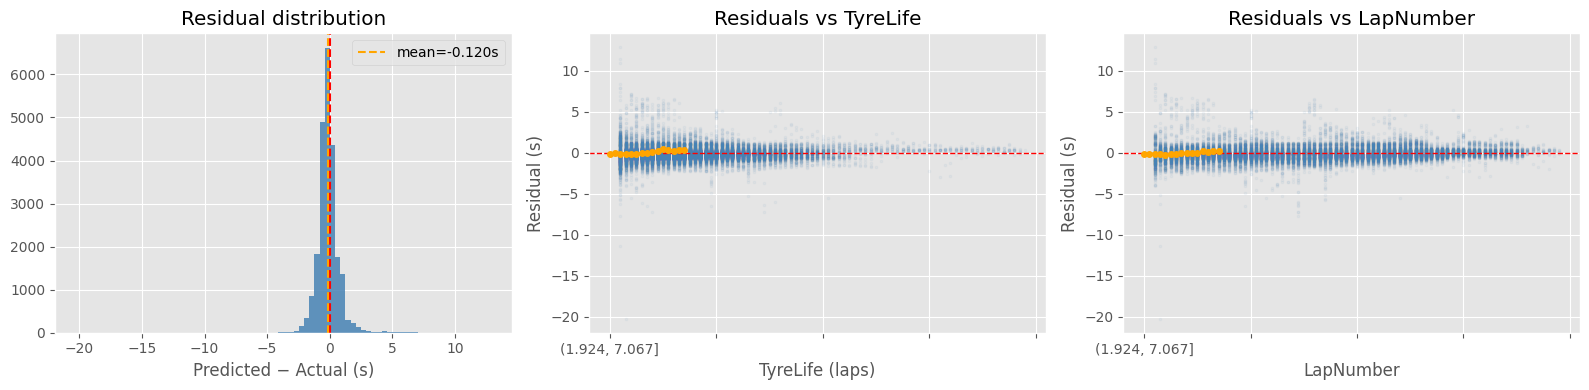

Residual mean  : -0.1199s  (bias)
Residual std   : 0.9183s
% within ±0.3s : 35.4%
% within ±0.5s : 55.6%
% within ±1.0s : 82.9%

Mean residual by Compound:
Compound
SOFT           -0.2572
MEDIUM         -0.1168
HARD           -0.2162
INTERMEDIATE    0.6399
WET             1.1025

Mean residual by race_phase:
race_phase
early   -0.1211
mid     -0.1571
late    -0.0830


In [20]:
def plot_residual_analysis(df_val, X_val, model, outputs_path):
    df = df_val.copy()
    df['pred']     = model.predict(X_val)
    df['residual'] = df['pred'] - df['LapTime_s']

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].hist(df['residual'], bins=80, color='steelblue', edgecolor='none', alpha=0.85)
    axes[0].axvline(0, color='red', lw=1.5, ls='--')
    axes[0].axvline(df['residual'].mean(), color='orange', lw=1.5, ls='--',
                    label=f"mean={df['residual'].mean():.3f}s")
    axes[0].set_title('Residual distribution')
    axes[0].set_xlabel('Predicted − Actual (s)')
    axes[0].legend()

    axes[1].scatter(df['TyreLife'], df['residual'], alpha=0.05, s=4, color='steelblue')
    axes[1].axhline(0, color='red', lw=1, ls='--')
    pd.cut(df['TyreLife'], bins=15).pipe(lambda b: df.groupby(b)['residual'].mean()).plot(
        ax=axes[1], color='orange', lw=2, marker='o', ms=4)
    axes[1].set_title('Residuals vs TyreLife')
    axes[1].set_xlabel('TyreLife (laps)')
    axes[1].set_ylabel('Residual (s)')

    axes[2].scatter(df['LapNumber'], df['residual'], alpha=0.05, s=4, color='steelblue')
    axes[2].axhline(0, color='red', lw=1, ls='--')
    pd.cut(df['LapNumber'], bins=15).pipe(lambda b: df.groupby(b)['residual'].mean()).plot(
        ax=axes[2], color='orange', lw=2, marker='o', ms=4)
    axes[2].set_title('Residuals vs LapNumber')
    axes[2].set_xlabel('LapNumber')
    axes[2].set_ylabel('Residual (s)')

    plt.tight_layout()
    plt.savefig(outputs_path / 'residual_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Residual mean  : {df['residual'].mean():.4f}s  (bias)")
    print(f"Residual std   : {df['residual'].std():.4f}s")
    print(f"% within ±0.3s : {(df['residual'].abs() < 0.3).mean()*100:.1f}%")
    print(f"% within ±0.5s : {(df['residual'].abs() < 0.5).mean()*100:.1f}%")
    print(f"% within ±1.0s : {(df['residual'].abs() < 1.0).mean()*100:.1f}%")

    comp_inv  = {v: k for k, v in COMPOUND_MAP.items()}
    phase_inv = {v: k for k, v in RACEPHASE_MAP.items()}
    print("\nMean residual by Compound:")
    print(df.groupby('Compound')['residual'].mean().rename(index=comp_inv).to_string())
    print("\nMean residual by race_phase:")
    print(df.groupby('race_phase')['residual'].mean().rename(index=phase_inv).to_string())

    return df


df24_res = plot_residual_analysis(df24, X_val, xgb_best, OUTPUTS)
